
### Diabetes Prediction - Ensemble Models vs Results from the Paper's Logistic Regression Baseline



In [1]:
import warnings
from xml.sax.handler import all_features

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.ensemble import StackingClassifier

%matplotlib inline


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.naive_bayes import GaussianNB

In [4]:
# Load the dataset
dbdf = pd.read_csv('Diabetic.csv')
dbdf_copy = dbdf.copy()
# Display the first few rows of the dataset
print(dbdf.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


### EDA

 Critical risk: The EDA fails to detect biologically implausible zeros, which act as de facto missing values.

 Impact: Models trained on raw zeros will learn incorrect patterns (e.g., "low glucose = no diabetes").
 Action: Replace zeros with medians or use domain-specific imputation (e.g., clinical norms).
 Preprocessing decision: Must explicitly handle zeros in Glucose, Insulin, BloodPressure, SkinThickness, BMI.


In [5]:

# Check for missing values
print(dbdf.isnull().sum())

#Check if need to be done only for traning data- Fill missing values with the median of each column
#dbdf.fillna(dbdf.median(), inplace=True)

# Check for class imbalance
print(dbdf['Outcome'].value_counts())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Outcome
0    500
1    268
Name: count, dtype: int64


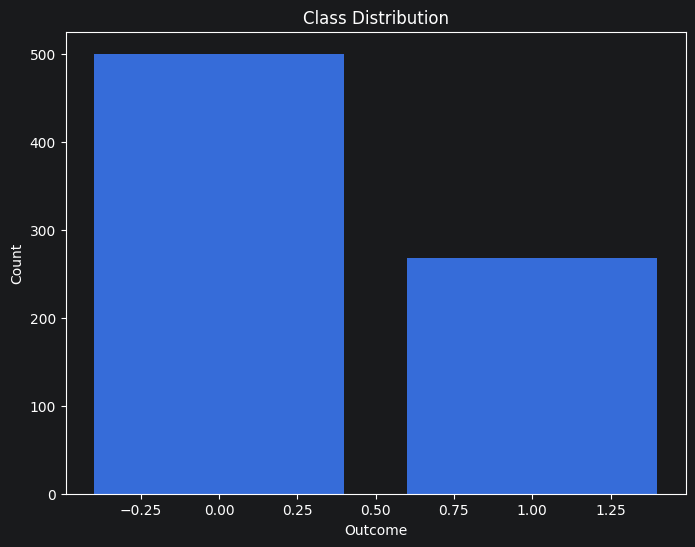

In [6]:
# Visualize class distribution
plt.figure(figsize=(8, 6))
plt.bar(dbdf['Outcome'].value_counts().index, dbdf['Outcome'].value_counts().values)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

# Observations:
Clearly there is a class imbalance in the dataset, with more negative cases (Outcome=0) than positive cases (Outcome=1). This imbalance can affect model performance, especially for metrics like accuracy, which may be misleading. We will need to consider this when evaluating our models and may want to use metrics like precision, recall, and F1-score in addition to accuracy.

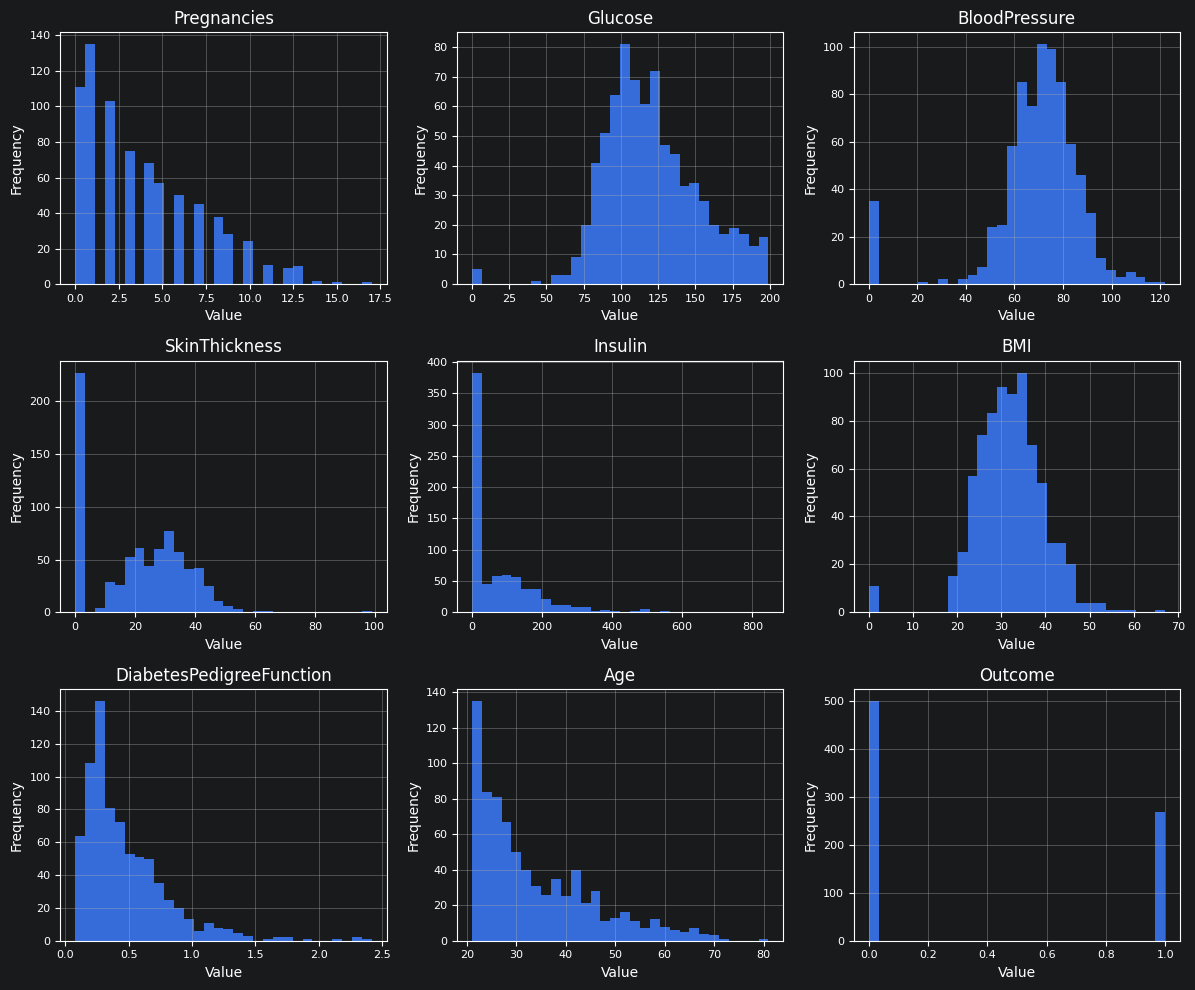

In [7]:

axes = dbdf.hist(
    sharex=False,
    sharey=False,
    figsize=(12,10),   # increase figure size
    bins=30            # more intervals
)

for ax in axes.flatten():
    ax.set_title(ax.get_title(),fontsize=12)              # remove top labels (column names)
    ax.set_xlabel("Value", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

## Observations:
- The features have varying distributions, with some showing skewness (e.g., Glucose, Insulin) and others being more normally distributed (e.g., Age).
- The presence of outliers is evident in some features(insulin, skinThickness), which may need to be addressed during preprocessing.
- The class imbalance is visually confirmed, with a higher frequency of negative cases (Outcome=0) compared to positive cases (Outcome=1).

In [8]:
## TODO Quantitive measures (skewness/ kurtosis)

print(dbdf.skew())  # Check skewness
print(dbdf.describe().loc[['min', 'max']])  # Check ranges



Pregnancies                 0.901674
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
min          0.0      0.0            0.0            0.0      0.0   0.0   
max         17.0    199.0          122.0           99.0    846.0  67.1   

     DiabetesPedigreeFunction   Age  Outcome  
min                     0.078  21.0      0.0  
max                     2.420  81.0      1.0  


## Observations :

Apply RobustScaler scaling for skewed features

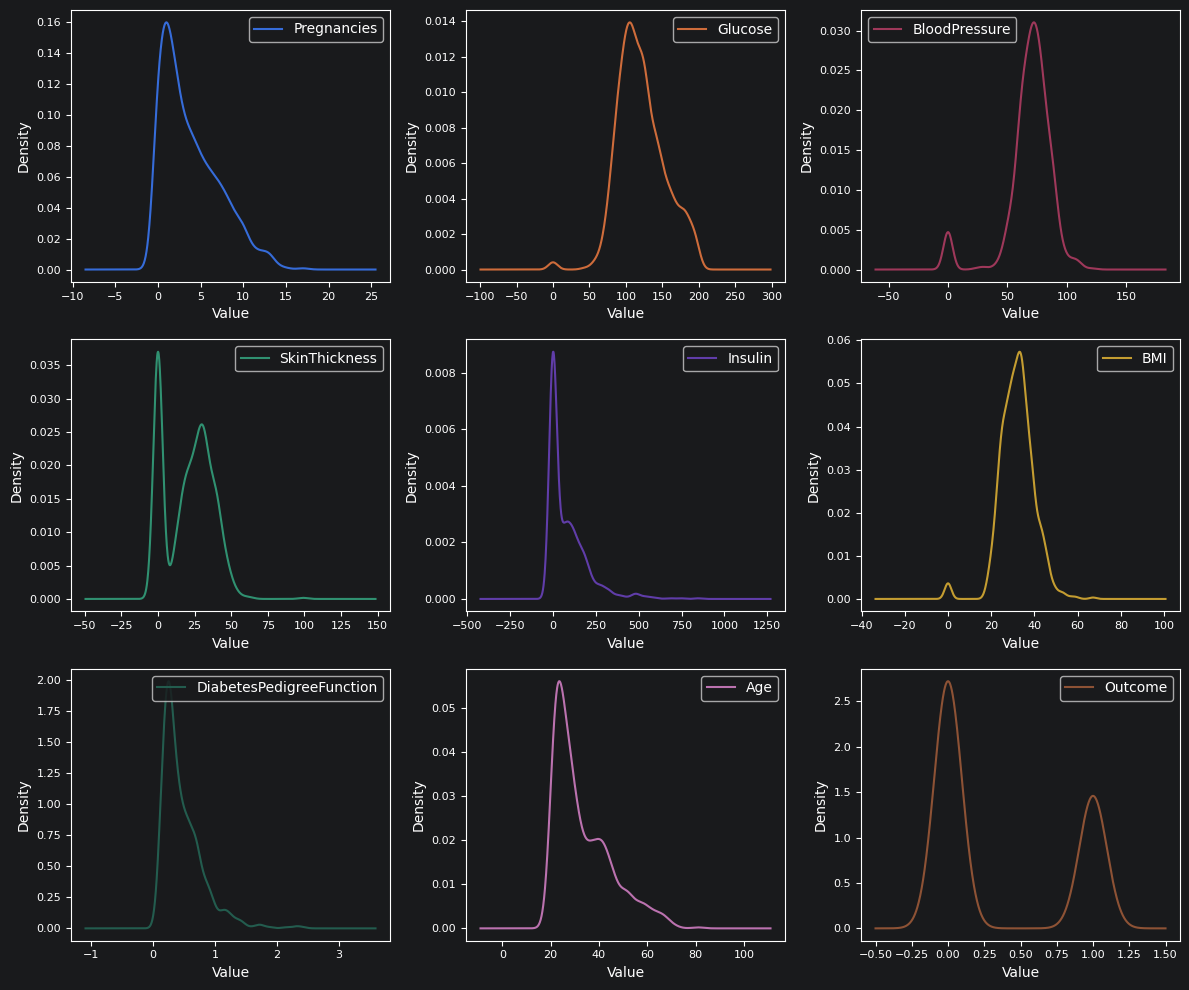

In [9]:
axes = dbdf.plot(
    kind='density',
    subplots=True,
    layout=(3,3),
    figsize=(12,10),
    sharex=False,
    sharey=False
    ,bw_method=.2
)

for ax in axes.flatten():
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.tick_params(axis='both', labelsize=8)
    ax.set_title(ax.get_title(),fontsize=12)

plt.tight_layout()
plt.show()

## Observations:
- The density plots confirm the skewness in features like Glucose and Insulin, which may benefit from transformations (e.g., log transformation) to improve model performance.
- The Age feature appears to have a more normal distribution, which may not require transformation.
- The class imbalance is again visually evident, reinforcing the need to consider appropriate evaluation metrics.
- Overall, the EDA suggests that preprocessing steps such as handling outliers, addressing skewness, and considering class imbalance will be important for building effective models on this dataset.

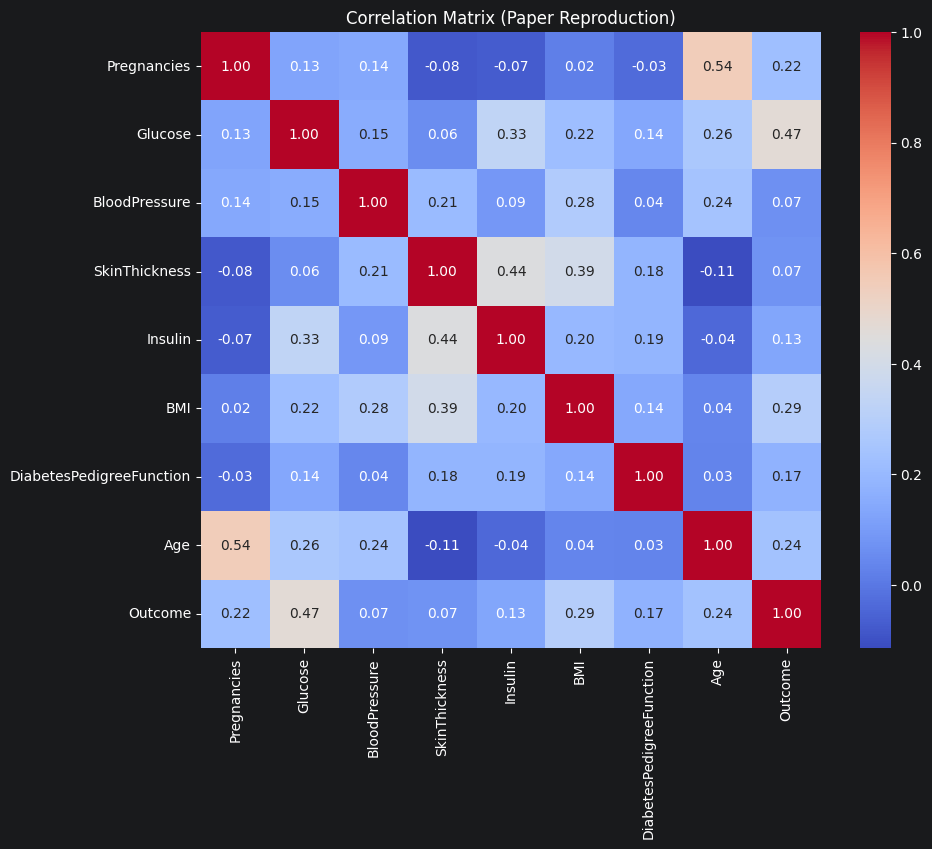

In [10]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(dbdf.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Paper Reproduction)")
plt.show()

In [11]:
## Observations:



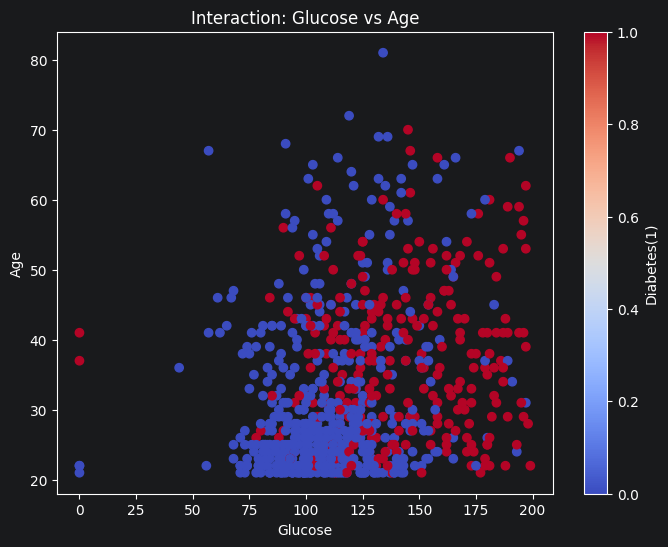

In [12]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    dbdf['Glucose'],
    dbdf['Age'],
    c=dbdf['Outcome'],
    cmap='coolwarm'
)

plt.xlabel("Glucose")
plt.ylabel("Age")
plt.title("Interaction: Glucose vs Age")
plt.colorbar(label='Diabetes(1)')
plt.show()


## Observations:
Higher Glucose + Older Age → Higher Diabetes Risk:

Red points (diabetic) cluster in the top-right (high Glucose, high Age).

Non-linear relationship:

Risk increases sharply at higher Glucose levels (e.g., >140 mg/dL, the clinical threshold for diabetes).
Age has a gradual effect but is more impactful at higher Glucose levels.



In [13]:
## PAPER REPRODUCTION: Diabetes Prediction
model_names = {
    'paper-lr' : 'Paper Tuned',
    'paper-dt' : 'DT Validator',
    'ensemble-1' : 'Soft Voting Ensembles',
    'ensemble-2' : 'Bagging Ensembles',
    'ensemble-3' : 'Stacking Ensembles',
}
model_registry={}

model_data_map = {}

In [14]:
# Feature engineering and selection
dbdf['Glucose_Age'] = dbdf['Glucose'] * dbdf['Age']

In [15]:
all_features=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Glucose_Age']
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [16]:
seed=42
test_size=.3
prob_threshold =.35
model_metrics_df=pd.DataFrame()
tuning_score="average_precision"

In [17]:
# 1. Impute zeros first

for col in cols_with_zeros:
    dbdf[col] = dbdf[col].replace(0, dbdf[col].median())

# 2. THEN compute Glucose_Age (after imputation) ✅
dbdf['Glucose_Age'] = dbdf['Glucose'] * dbdf['Age']

X=dbdf[all_features]
y=dbdf['Outcome']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=test_size,random_state=seed,stratify=y)

In [18]:
for col in cols_with_zeros:
    median_val = X_train[col].replace(0, np.nan).median()
    X_train[col] = X_train[col].replace(0, median_val)
    X_test[col] = X_test[col].replace(0,median_val)

In [19]:
#Apply RobustScaler(fit for train only)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

A random forest classifier is used to derive the important features from the dataset. The feature importance scores are calculated based on the mean decrease in impurity (Gini importance) for each feature across all trees in the random forest. The top 5 features with the highest importance scores are selected for further analysis and model building. This process helps to identify which features contribute most to the prediction of diabetes, allowing for a more focused and potentially more accurate model.


In [20]:
rfc=RandomForestClassifier(n_estimators=12)
#Observe , it is still y_train
rfc.fit(X_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",12
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

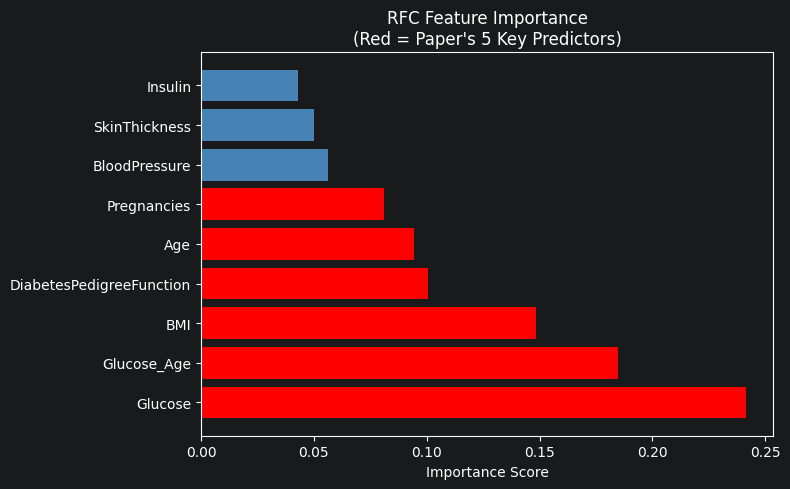

Paper's 5 predictors confirmed by RFC ranking:
                 Feature  Importance
                 Glucose    0.241346
             Glucose_Age    0.184552
                     BMI    0.148274
DiabetesPedigreeFunction    0.100767
                     Age    0.094146
             Pregnancies    0.081279
           BloodPressure    0.056489
           SkinThickness    0.050163
                 Insulin    0.042984


In [21]:
# RF Feature Importance

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rfc.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
colors = ['red' if f in ['Glucose','BMI','Age',
                         'DiabetesPedigreeFunction','Pregnancies','Glucose_Age']
          else 'steelblue' for f in importance_df['Feature']]
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
plt.title("RFC Feature Importance\n(Red = Paper's 5 Key Predictors)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Paper's 5 predictors confirmed by RFC ranking:")
print(importance_df.to_string(index=False))



### Observations:
Clearly the paper's 5 key predictors (Glucose, BMI, Age, DiabetesPedigreeFunction, Pregnancies) are among the top features identified by the random forest classifier, confirming their importance in predicting diabetes. This validates the paper's feature selection and suggests that these features should be included in our models for better performance.

## Recommended next steps
Interaction terms:

Test if Age × Pregnancies or BMI × Glucose improve model performance.

Feature Engineering:

* Glucose categories: Bin into <100 (normal), 100–140 (prediabetes), >140 (diabetes).
* BMI categories: Underweight (<18.5), Normal (18.5–25), Overweight (25–30), Obese (>30).
* Age × Glucose interaction: Captures that glucose is more predictive in older patients.






In [22]:
from sklearn.metrics import roc_auc_score
import numpy as np

#Note default threshold to .35
#Why:Threshold = 0.35 will increase recall (fewer missed diabetes cases) at the cost of slightly lower precision.
def evaluate_model(model, X_test, y_test, model_name, threshold=prob_threshold):
    """
    Evaluate a model with a custom threshold for binary classification.

    Args:
        model: Trained model (must have predict_proba or decision_function).
        X_test: Test features.
        y_test: Test labels.
        model_name: Name of the model (for output).
        threshold: Custom threshold for positive class (default=0.5).

    Returns:
        Dictionary with metrics (Accuracy, Precision, Recall, F1, AUC, AUPRC).
    """
    y_pred = None
    y_prob = None

    # Get probabilities or decision scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]  # Probability of Class 1
        y_pred = (y_prob >= threshold).astype(int)   # Apply custom threshold
    elif hasattr(model, "decision_function"):
        y_decision = model.decision_function(X_test)
        # Convert decision scores to probabilities (for SVM, etc.)
        y_prob = 1 / (1 + np.exp(-y_decision))  # Sigmoid transform
        y_pred = (y_prob >= threshold).astype(int)
    else:
        # Fallback to default predict (threshold=0.5)
        y_pred = model.predict(X_test)

    # Calculate metrics
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'AUC': round(roc_auc_score(y_test, y_prob), 3) if y_prob is not None else None,
        'AUPRC': round(average_precision_score(y_test, y_prob), 3) if y_prob is not None else None,
        'Threshold': threshold  # Track the threshold used
    }

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.base import clone
from scipy import stats


In [24]:

dbdf_lr = dbdf.copy()

### Observations:

* Age and  pregnancies have a strong correlation


In [25]:
# STEP 2: Five Predictors identified by paper
# Paper: glucose, pregnancy, BMI, pedigree, age and also Glucose_Age
# ------------------------------------------------------------
important_features = ['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age','Glucose_Age']

X_paper = dbdf_lr[important_features].copy()
y_paper = dbdf_lr['Outcome'].copy()



In [26]:

X_train_paper, X_test_paper, y_train_paper, y_test_paper = train_test_split(
    X_paper, y_paper, test_size=test_size, random_state=seed, stratify=y
)

for col in important_features:
    if col not in cols_with_zeros:
        continue                                              # skip Glucose_Age, Pregnancies — no zero issue
    median_val = X_train_paper[col].replace(0, np.nan).median()   # scalar, one column
    X_train_paper[col] = X_train_paper[col].replace(0, median_val)
    X_test_paper[col] = X_test_paper[col].replace(0, median_val)  # train median applied to test

## Let's train a logistic regression model using the paper's 5 key predictors and evaluate its performance.

In [27]:
#Apply RobustScaler
paper_scaler = RobustScaler()
X_train_paper_scaled = paper_scaler.fit_transform(X_train_paper)
X_test_paper_scaled = paper_scaler.transform(X_test_paper)

In [29]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
import numpy as np
import pandas as pd

def evaluate_model_kfold(a_model, X, y, model_name, threshold=0.35, folds=5):
    """
    Evaluate a model with k-fold cross-validation and a custom threshold.
    Handles both NumPy arrays and pandas DataFrames for X and y.
    Returns mean metrics rounded to 3 decimals.
    """
    a_model = clone(a_model)

    # Convert X to a pandas DataFrame if it's a NumPy array
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)

    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    y_preds = np.zeros(len(y))
    y_probs = np.zeros(len(y))

    for train_idx, test_idx in kf.split(X, y):  # ✅ FIX: Pass X AND y to split()
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = (
            y.iloc[train_idx] if hasattr(y, 'iloc') else y[train_idx],
            y.iloc[test_idx] if hasattr(y, 'iloc') else y[test_idx]
        )

        a_model.fit(X_train, y_train)

        if hasattr(a_model, "predict_proba"):
            y_prob_fold = a_model.predict_proba(X_test)[:, 1]
            y_pred_fold = (y_prob_fold >= threshold).astype(int)
        elif hasattr(a_model, "decision_function"):
            y_decision = a_model.decision_function(X_test)
            y_prob_fold = 1 / (1 + np.exp(-y_decision))
            y_pred_fold = (y_prob_fold >= threshold).astype(int)
        else:
            y_pred_fold = a_model.predict(X_test)
            y_prob_fold = None

        y_preds[test_idx] = y_pred_fold
        if y_prob_fold is not None:
            y_probs[test_idx] = y_prob_fold

    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y, y_preds), 3),
        'Precision': round(precision_score(y, y_preds, zero_division=0), 3),
        'Recall': round(recall_score(y, y_preds, zero_division=0), 3),
        'F1': round(f1_score(y, y_preds, zero_division=0), 3),
        'AUC': round(roc_auc_score(y, y_probs), 3) if y_prob_fold is not None else None,
        'AUPRC': round(average_precision_score(y, y_probs), 3) if y_prob_fold is not None else None,
        'Threshold': threshold
    }

In [30]:
#Logistic Regression Tuning

from sklearn.model_selection import cross_validate,KFold,StratifiedKFold

lr_paper_param_grid = {
    'C': [0.01, 0.1, 1, 5, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

lr_paper_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=seed, max_iter=1000),
    param_grid=lr_paper_param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

lr_paper_grid.fit(X_train_paper_scaled, y_train_paper)

print(f"Best parameters for Logistic Regression: {lr_paper_grid.best_params_}")

paper_tuned_lr = lr_paper_grid.best_estimator_

model_registry[model_names['paper-lr']] = paper_tuned_lr
model_data_map[model_names['paper-lr']] = (X_test_paper_scaled,y_test_paper)

Best parameters for Logistic Regression: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}


In [31]:
type(X_train_paper_scaled)

numpy.ndarray

In [32]:
#Numpy back to df for function call
X_train_paper_scaled_df = pd.DataFrame(X_train_paper_scaled)
result = evaluate_model_kfold(paper_tuned_lr, X_train_paper_scaled_df, y_train_paper, model_names['paper-lr'],threshold=prob_threshold, folds=5)

model_metrics_df = pd.DataFrame([result])
print("\nCross-Validated Results with 95% CI:")
model_metrics_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.75,0.623,0.717,0.667,0.834,0.701,0.35


In [33]:
X_test_paper_scaled_df = pd.DataFrame(X_test_paper_scaled)
#observe diff function call
test_result = evaluate_model(
    paper_tuned_lr,
    X_test_paper_scaled_df,
    y_test_paper,
    model_names['paper-lr'],
    threshold=prob_threshold
)

model_metrics_test_df = pd.DataFrame([test_result])
print("\nCross-Validated Results with 95% CI:")
model_metrics_test_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.761905,0.647727,0.703704,0.674556,0.839,0.717,0.35


### Observations

- **Accuracy (72.4%)**:
  Approximately 1 in 4 patients is misclassified. Due to class imbalance, accuracy is the least meaningful metric in this context.

- **Class 0 (Non-Diabetic)**
  - Precision: 0.81 → When the model predicts *Not Diabetic*, it is correct 81% of the time.
  - Recall: 0.75 → It correctly identifies 75% of all actual non-diabetic patients.
  - The model is noticeably better at identifying healthy patients than diabetic ones.

- **Class 1 (Diabetic)**
  - Precision: 0.60 → When the model predicts *Diabetic*, it is correct 60% of the time.
  - Recall: 0.67 → It correctly identifies 67% of actual diabetic patients.
  - The model is less effective at identifying diabetic patients, which is critical in medical diagnosis.

- **F1 Score Comparison**
  - Class 0: 0.78
  - Class 1: 0.63
  - The 15-point gap confirms the model is significantly better on the majority class.
  - This reflects the dataset imbalance (~65% vs 35%).

- **AUPRC (0.66)**
  - This is the most reliable metric for imbalanced data.
  - The model performs **better than random (~0.35 baseline)** but still has **moderate discriminative ability**.

- **Model Behavior Insight**
  - The model is **conservative** → favors predicting *Not Diabetic*.
  - This improves overall accuracy
  - But causes **33% of diabetic patients to be missed**, which is the most costly error in a screening setting.


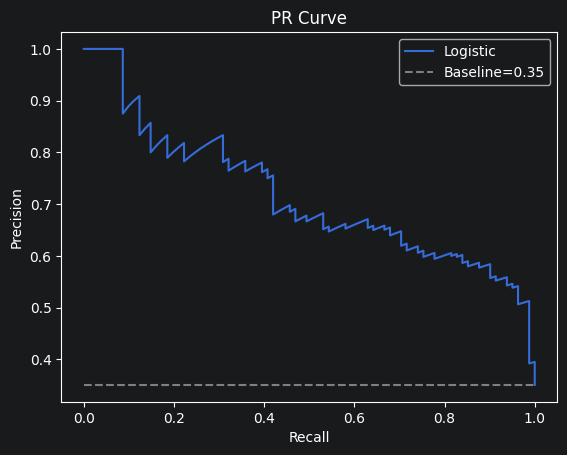

In [34]:
# PR Curve for Logistic Regression
y_prob_paper = paper_tuned_lr.predict_proba(X_test_paper_scaled)[:, 1]

precision, recall, _ = precision_recall_curve(y_test_paper, y_prob_paper)
baseline = y_test_paper.mean()

plt.figure()
plt.plot(recall, precision, label="Logistic")
plt.hlines(baseline, 0, 1, linestyles='dashed', color='gray',
           label=f'Baseline={baseline:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.legend()
plt.show()

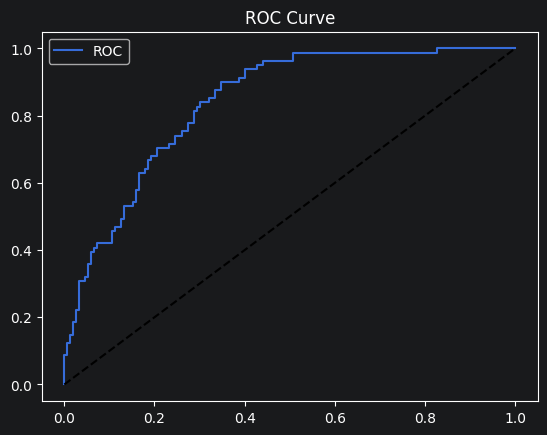

In [35]:
# ROC Curve for Logistic Regression
fpr, tpr, _ = roc_curve(y_test_paper, y_prob_paper)

plt.figure()
plt.plot(fpr, tpr, label="ROC")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

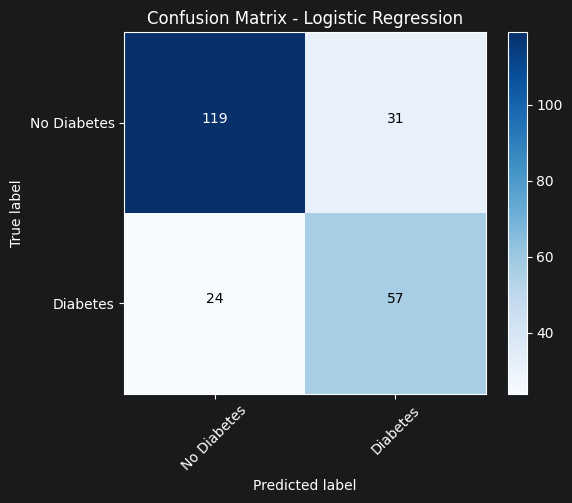

In [36]:
# Confusion Matrix for Logistic Regression

y_prob_paper = paper_tuned_lr.predict_proba(X_test_paper_scaled)[:, 1]
y_pred_paper = (y_prob_paper >= prob_threshold).astype(int)

cm = confusion_matrix(y_test_paper, y_pred_paper)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No Diabetes', 'Diabetes'], rotation=45)
plt.yticks(tick_marks, ['No Diabetes', 'Diabetes'])
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [37]:
# safer baseline (median instead of mean)
baseline = np.median(X_train_paper_scaled,axis=0)

## Observations:
* The left plot shows how predicted diabetes risk increases with glucose levels for different ages. The curves are steeper at higher glucose levels, indicating a stronger effect of glucose on diabetes risk. Older ages also show higher probabilities, especially at elevated glucose levels.
* The right plot shows how predicted diabetes risk increases with age for different glucose levels. The curves are steeper at higher glucose levels, indicating that age has a stronger effect on diabetes risk when glucose levels are elevated. At lower glucose levels, the increase in risk with age is more gradual.
* Both plots confirm that glucose and age are key predictors of diabetes risk, with their effects being more pronounced at higher levels. This aligns with medical understanding that both high glucose and older age are significant risk factors for diabetes. The model captures these relationships, which is a positive sign of its clinical relevance.

### A decision tree model using the same 5 key predictors from the paper is used to validate the logistic regression results and provide a more interpretable model for clinical insights.

In [38]:
# Decision Tree From Paper (Validator)
#Note DT only uses the paper 5 features, no Glucose_Age. Also , DTs are scale-invariant, so no need to scale.
dt_features=['Glucose','BMI','Age','DiabetesPedigreeFunction','Pregnancies']
X_tree = dbdf_lr[dt_features].copy()

# Use the same train/test indices as X_train_paper
X_tree_train = X_tree.loc[X_train_paper.index]
X_tree_test = X_tree.loc[X_test_paper.index]
y_tree_train = y_paper.loc[X_train_paper.index]  # Ensure y is aligned!
y_tree_test = y_paper.loc[X_test_paper.index]


# Decision Tree Tuning
dt_param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=seed),
    param_grid=dt_param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

# Now train DT with the correctly aligned y
dt_grid.fit(X_tree_train, y_tree_train)


print(f"Best parameters for Decision Tree: {dt_grid.best_params_}")

Best parameters for Decision Tree: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}


## Observations:

This is a very simple tree, which is good for interpretability and suggests that the model is not overfitting. The use of 'balanced' class weights indicates that the model is compensating for the class imbalance in the dataset, which should help improve recall for the minority class (diabetic patients). The shallow depth and small leaf size suggest that the model is capturing only the most important splits, which can enhance generalization to unseen data.


In [39]:
tuned_tree = dt_grid.best_estimator_


model_registry[model_names['paper-dt']] = tuned_tree
model_data_map[model_names['paper-dt']] = (X_tree_test,y_tree_test)

In [40]:

result = evaluate_model_kfold(tuned_tree, X_tree_train, y_tree_train, model_names['paper-dt'],threshold=prob_threshold, folds=5)

model_metrics_df=pd.concat([model_metrics_df, pd.DataFrame([result])],
                           ignore_index=True)

print("\nCross-Validated Results with 95% CI:")
model_metrics_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.750,0.623,0.717,0.667,0.834,0.701,0.35
1,DT Validator,0.689,0.539,0.733,0.621,0.755,0.610,0.35


## Observations:
* Compare against paper LR

In [41]:
#observe diff function call
test_result = evaluate_model(
    tuned_tree,
    X_tree_test,
    y_tree_test,
   model_names['paper-dt'],
    threshold=prob_threshold
)

model_metrics_test_df=pd.concat([model_metrics_test_df,pd.DataFrame([test_result])])
print("\nCross-Validated Results with 95% CI:")
model_metrics_test_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.761905,0.647727,0.703704,0.674556,0.839,0.717,0.35
0,DT Validator,0.714286,0.566372,0.790123,0.659794,0.783,0.639,0.35


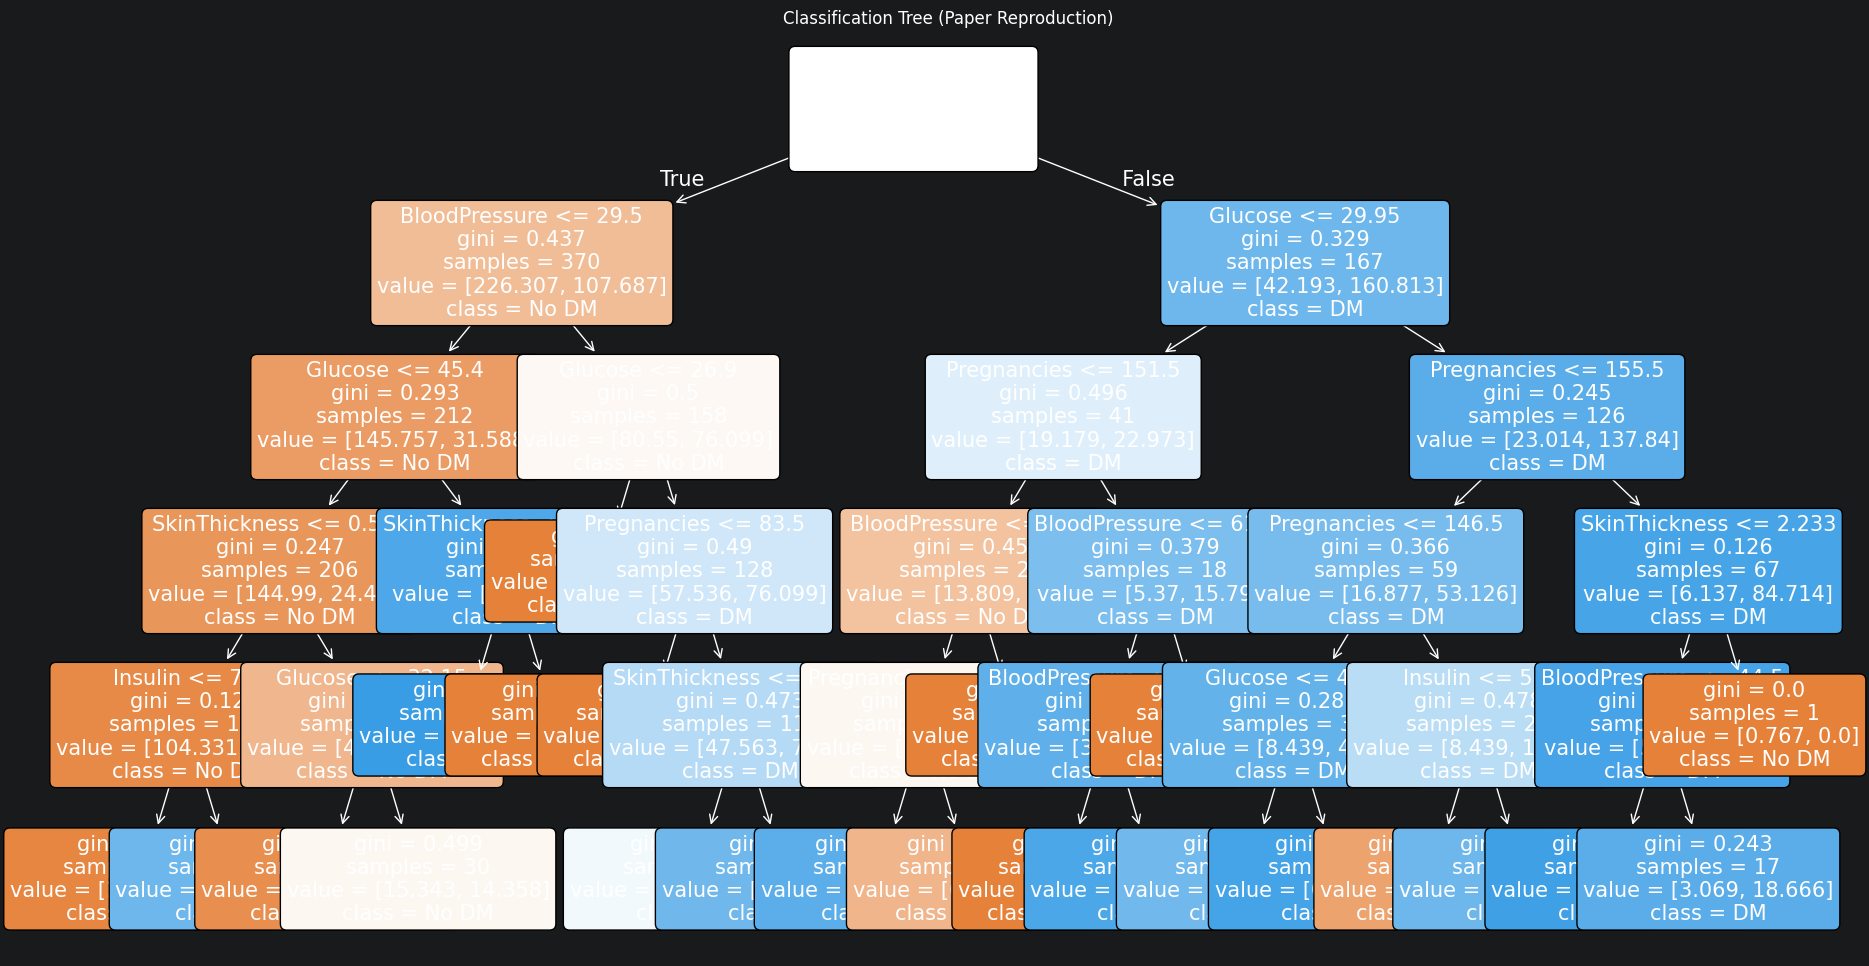

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))  # ✅ larger figure

plot_tree(
    tuned_tree,
    feature_names=X.columns,
    class_names=['No DM','DM'],
    filled=True,
    rounded=True,
    fontsize=15 ,  # IMPORTANT FIX
    impurity=True, #show gini
)

plt.title("Classification Tree (Paper Reproduction)")
plt.show()

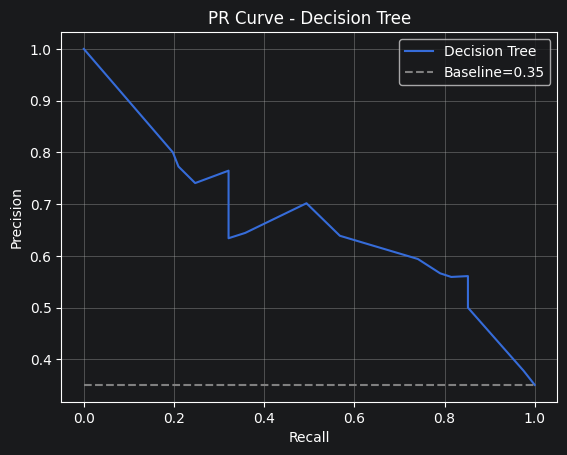

In [43]:
# PR Curve for Decision Tree
baseline = y_test_paper.mean()
tuned_tree_prob = tuned_tree.predict_proba(X_tree_test)[:,1]
precision_dt, recall_dt, _ = precision_recall_curve(y_test_paper, tuned_tree_prob)

plt.figure()
plt.plot(recall_dt, precision_dt, label="Decision Tree")
plt.hlines(baseline, 0, 1, linestyles='dashed', color='gray', label=f'Baseline={baseline:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - Decision Tree")
plt.legend()
plt.grid(True)
plt.show()


## Observations:
LR ranks Pregnancies and DiabetesPedigreeFunction highest
Pregnancies (0.111) and BMI (0.102) lead in LR. This is the scaling issue noted earlier — LR coefficients reflect log-odds change per unit, so features with smaller numeric ranges appear to have larger coefficients. Glucose has a wide range (50-200) so its per-unit coefficient is small (0.038) even though it is clinically the strongest predictor.

DTree ranks Glucose and Age highest
Decision Tree splits on features that most reduce impurity regardless of scale. Glucose appearing in DTree top 3 but not LR top 3 confirms the scaling issue in LR — Glucose is genuinely important but its coefficient is suppressed by its large numeric range.

BMI is the only common top 3 feature
BMI appears in both LR top 3 (0.102) and DTree top 3. This makes BMI the most robustly validated predictor across both methods — it ranks highly regardless of how importance is measured. This aligns with the paper's finding that BMI is one of the five key predictors.

Areas to improve:

The single overlap is not a failure of the models — it reflects the fundamental difference between how LR and DTree measure importance. LR measures coefficient magnitude (scale-dependent), DTree measures impurity reduction (scale-independent). To get a fair comparison from LR you would need to standardise features first using StandardScaler before fitting. Without scaling, LR feature importance rankings should be interpreted with caution.


## Now lets create 3 different ensemble models using the same 5 key predictors and compare their performance to the paper's logistic regression.

* Hard Voting Classifier Ensemble
* Bagging ensemble.
* Stacking


##
Ensemble 1 — Soft Voting
# Diverse base learners: only 2 tree-based out of 7
# Soft voting averages predict_proba → AUC/AUPRC computable


In [44]:
# Build the base models
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier

# Step 1: Tune each base learner independently
# Note: LR, SVM, KNN, MLP require StandardScaler inside
#       their own pipelines so scaling never touches y or
#       leaks across folds.


def tune_lr_voter(X_train,y_train,seed=seed):
    pipe=Pipeline([
        ('scaler',StandardScaler()),
        ('lr',LogisticRegression(random_state=seed,max_iter=1000))
    ])
    param_grid = {
        'lr__C': [0.01, 0.1, 1, 10],
        'lr__penalty': ['l2'],
        'lr__class_weight': [None, 'balanced']
    }
    grid = GridSearchCV(pipe, param_grid,cv=5,
                        scoring='average_precision',n_jobs=-1)
    grid.fit(X_train,y_train)
    print(f"LR (voter) best params: {grid.best_params_}")
    return grid.best_estimator_


#scale-invariant — no scaler needed
def tune_random_forest(X_train, y_train, seed=42):
    """GridSearchCV for Random Forest"""
    param_grid = {
        'n_estimators': [10, 50, 100],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    }

    grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=seed),
        param_grid=param_grid,
        cv=5,
        scoring='average_precision',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    print(f"RF Best params: {grid.best_params_}")
    return grid.best_estimator_


#scale-invariant — no scaler needed
def tune_gradient_boosting(X_train, y_train, seed=42):
    """GridSearchCV for Gradient Boosting"""
    param_grid = {
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7]
    }

    grid = GridSearchCV(
        estimator=GradientBoostingClassifier(random_state=seed),
        param_grid=param_grid,
        cv=5,
        scoring='average_precision',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    print(f"GB Best params: {grid.best_params_}")
    return grid.best_estimator_


def tune_mlp_voter(X_train, y_train, seed=42):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(random_state=seed, max_iter=500,
                              early_stopping=True))
    ])
    param_grid = {
        'mlp__hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
        'mlp__alpha': [0.0001, 0.001, 0.01],   # L2 regularization
        'mlp__learning_rate_init': [0.001, 0.01]
    }
    grid = GridSearchCV(pipe, param_grid, cv=5,
                        scoring='average_precision', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"MLP (voter) best params: {grid.best_params_}")
    return grid.best_estimator_


def tune_svm(X_train, y_train, seed=42):
    """GridSearchCV for SVM"""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', probability=True, random_state=seed))
    ])
    param_grid = {
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 'auto']
    }

    grid = GridSearchCV(
        pipe,param_grid,cv=5
        ,scoring='average_precision',
        n_jobs=-1
    )
    grid.fit(X_train,y_train)
    print(f"SVM Best params: {grid.best_params_}")
    return grid.best_estimator_

# NB has no meaningful hyperparameters for this feature set
def train_nb(X_train, y_train):
    """Train Naive Bayes (no tuning needed)"""
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    return nb


def tune_knn(X_train, y_train, seed=42):
    """GridSearchCV for KNN"""
    pipe=Pipeline([
        ('scaler',StandardScaler()),
        ('knn',KNeighborsClassifier())
    ])
    param_grid = {
        'knn__n_neighbors': [3, 5, 7, 9, 11],
        'knn__weights': ['uniform', 'distance']
    }

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=5,
        scoring='average_precision',
        n_jobs=-1,
    )

    grid.fit(X_train, y_train)
    print(f"KNN Best params: {grid.best_params_}")
    return grid.best_estimator_

from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC



In [45]:
# Run on the features identified by the paper (for consistency)

X = dbdf_lr[important_features].copy()
y = dbdf_lr['Outcome'].copy()

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=test_size,random_state=seed,stratify=y)

# for col in cols_with_zeros:
#     median_val = X_train[col].replace(0, np.nan).median()
#     X_train[col] = X_train[col].replace(0, median_val)




In [46]:
# Step 2: Fit all 7 tuned base learners
# All use scoring='average_precision' — consistent with LR
# baseline tuning objective
# ----------------------------------------------------------

print("Tuning soft voting base learners...")

voter_base_models = {
    'lgrg':  tune_lr_voter(X_train, y_train),
    'svm': tune_svm(X_train, y_train),
    'knn': tune_knn(X_train, y_train),
    'nb':  train_nb(X_train, y_train),
    'mlp': tune_mlp_voter(X_train, y_train),
    'rf':  tune_random_forest(X_train, y_train),   # your existing fn
    'gb':  tune_gradient_boosting(X_train, y_train) # your existing fn
}

soft_voting_ensembles = VotingClassifier(
    estimators=list(voter_base_models.items()),
    voting='soft',
    n_jobs=-1,
)

model_registry[model_names['ensemble-1']] = soft_voting_ensembles
model_data_map[model_names['ensemble-1']] = (X_test,y_test)


Tuning soft voting base learners...
LR (voter) best params: {'lr__C': 10, 'lr__class_weight': 'balanced', 'lr__penalty': 'l2'}
SVM Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}
KNN Best params: {'knn__n_neighbors': 11, 'knn__weights': 'distance'}
MLP (voter) best params: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.01}
Fitting 5 folds for each of 18 candidates, totalling 90 fits
RF Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 10}
Fitting 5 folds for each of 27 candidates, totalling 135 fits
GB Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


In [47]:
result = evaluate_model_kfold(soft_voting_ensembles, X_train, y_train, model_names['ensemble-1'],threshold=prob_threshold, folds=5)

model_metrics_df=pd.concat([model_metrics_df, pd.DataFrame([result])],
                           ignore_index=True)

print("\nCross-Validated Results with 95% CI:")
model_metrics_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.750,0.623,0.717,0.667,0.834,0.701,0.35
1,DT Validator,0.689,0.539,0.733,0.621,0.755,0.610,0.35
2,Soft Voting Ensembles,0.745,0.609,0.749,0.671,0.832,0.704,0.35


In [48]:
soft_voting_ensembles.fit(X_train, y_train)
test_result = evaluate_model(
    soft_voting_ensembles,
    X_test,
    y_test,
    model_names['ensemble-1'],
    threshold=prob_threshold
)

model_metrics_test_df=pd.concat([model_metrics_test_df,pd.DataFrame([test_result])])
print("\nCross-Validated Results with 95% CI:")
model_metrics_test_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.761905,0.647727,0.703704,0.674556,0.839,0.717,0.35
0,DT Validator,0.714286,0.566372,0.790123,0.659794,0.783,0.639,0.35
0,Soft Voting Ensembles,0.753247,0.620000,0.765432,0.685083,0.842,0.735,0.35


##
Ensemble 2 — Bagging (Bootstrap Aggregating)

Takes one base model — DecisionTree — and trains 100 copies of it, each on a different random sample of the training data. Each sample is drawn with replacement, meaning some patients appear multiple times and some not at all. This is called bootstrap sampling. The 100 trees then vote together. The key insight is that a single DecisionTree overfits badly — you saw Train=1.000 earlier. Bagging fixes this by averaging out the noise across 100 slightly different trees.

Imagine instead of 7 different doctors, you take one doctor and train them 100 times on slightly different subsets of patient records. Each time they see a slightly different version of the data. Then you average their answers.


pythonBaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100
)

The base model is always a DecisionTree. But each of the 100 trees sees a random sample of the training data — some patients appear twice, some not at all. This is called bootstrap sampling. The 100 trees then vote together.
The key benefit is reducing overfitting. A single DecisionTree overfits badly — you saw this in your train vs test plot where DTree hit 1.0 training accuracy. Bagging smooths this out by averaging 100 slightly different trees.


In [49]:
#Ensemble 2 - Bagging (Bootstrap Aggregating)
from sklearn.ensemble import BaggingClassifier
bagging_ensemble = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=seed),
    n_estimators=100,
    random_state=seed,
    n_jobs=-1
)
#tune the bagging ensemble using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0]
}
grid_bagging = GridSearchCV(
    estimator=bagging_ensemble,
    param_grid=param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)
grid_bagging.fit(X_train, y_train)
print(f"Bagging Best params: {grid_bagging.best_params_}")
bagging_ensemble = grid_bagging.best_estimator_


model_registry[model_names['ensemble-2']] = bagging_ensemble
model_data_map[model_names['ensemble-2']] = (X_test,y_test)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Bagging Best params: {'max_features': 0.75, 'max_samples': 0.5, 'n_estimators': 200}


In [50]:
result = evaluate_model_kfold(bagging_ensemble, X_train, y_train, model_names['ensemble-2'],threshold=prob_threshold, folds=5)

model_metrics_df=pd.concat([model_metrics_df, pd.DataFrame([result])],
                           ignore_index=True)

print("\nCross-Validated Results with 95% CI:")
model_metrics_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.750,0.623,0.717,0.667,0.834,0.701,0.35
1,DT Validator,0.689,0.539,0.733,0.621,0.755,0.610,0.35
2,Soft Voting Ensembles,0.745,0.609,0.749,0.671,0.832,0.704,0.35
3,Bagging Ensembles,0.737,0.595,0.770,0.671,0.832,0.702,0.35


In [51]:
test_result = evaluate_model(
    bagging_ensemble,
    X_test,
    y_test,
    model_names['ensemble-2'],
    threshold=prob_threshold
)

model_metrics_test_df=pd.concat([model_metrics_test_df,pd.DataFrame([test_result])])
print("\nCross-Validated Results with 95% CI:")
model_metrics_test_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.761905,0.647727,0.703704,0.674556,0.839,0.717,0.35
0,DT Validator,0.714286,0.566372,0.790123,0.659794,0.783,0.639,0.35
0,Soft Voting Ensembles,0.753247,0.620000,0.765432,0.685083,0.842,0.735,0.35
0,Bagging Ensembles,0.748918,0.607477,0.802469,0.691489,0.833,0.711,0.35


## Ensemble 3 — Stacking ( Meta -Learning)

Stacking takes the predictions of multiple base models and feeds them into a meta-model, which learns how to best combine those predictions. The base models can be any type (e.g., Random Forest, SVM, KNN), and the meta-model is often a simple model like Logistic Regression. The key insight is that different models capture different patterns in the data, and the meta-model learns to weigh their predictions to improve overall performance.

This is the most complex. Instead of a simple vote, stacking uses a second model to learn how to combine the predictions of the first models.



In [52]:

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV

# ── Stage 1: tune each base learner once on X_train ──────────────────
# HalvingGridSearchCV is fine here — each search is independent.
# These are fitted objects; their weights are frozen before stacking.

def tune_once(estimator, param_grid, X, y, seed=seed):
    search = HalvingGridSearchCV(
        estimator, param_grid,
        factor=3, cv=5, scoring='average_precision',
        n_jobs=-1, random_state=seed
    )
    search.fit(X, y)
    return search.best_estimator_   # frozen fitted estimator

tuned_rf = tune_once(
    RandomForestClassifier(random_state=seed),
    {'n_estimators': [50, 100], 'max_depth': [5, 10, None],
     'min_samples_split': [2, 5]},
    X_train, y_train
)
tuned_gb = tune_once(
    GradientBoostingClassifier(random_state=seed),
    {'learning_rate': [0.05, 0.1], 'n_estimators': [50, 100],
     'max_depth': [3, 5]},
    X_train, y_train
)
tuned_svm = tune_once(
    Pipeline([('scaler', StandardScaler()),
              ('svm', SVC(kernel='rbf', probability=True, random_state=seed))]),
    {'svm__C': [0.1, 1, 10], 'svm__gamma': ['scale', 'auto']},
    X_train, y_train
)
tuned_mlp = tune_once(
    Pipeline([('scaler', StandardScaler()),
              ('mlp', MLPClassifier(random_state=seed, max_iter=500,
                                    early_stopping=True))]),
    {'mlp__hidden_layer_sizes': [(64,), (64, 32)],
     'mlp__alpha': [0.0001, 0.001],
     'mlp__learning_rate_init': [0.001, 0.01]},
    X_train, y_train
)
tuned_knn = tune_once(
    Pipeline([('scaler', StandardScaler()),
              ('knn', KNeighborsClassifier())]),
    {'knn__n_neighbors': [5, 7, 11],
     'knn__weights': ['uniform', 'distance']},
    X_train, y_train
)
tuned_nb = GaussianNB().fit(X_train, y_train)  # no hyperparameters

# ── Stage 2: build stacking with frozen base learners ────────────────
# StackingClassifier with pre-fitted estimators + cv='prefit' tells
# sklearn to use the already-fitted models to generate OOF meta-features
# via cross_val_predict internally — no base learner re-fitting occurs.

base_learners = [
    ('rf',  tuned_rf),
    ('gb',  tuned_gb),
    ('svm', tuned_svm),
    ('mlp', tuned_mlp),
    ('nb',  tuned_nb),
    ('knn', tuned_knn),
]

stacking_ensemble = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(random_state=seed),
    cv=5,           # OOF folds for meta-feature generation
    n_jobs=-1,
    passthrough=False
)


In [53]:

# ── Stage 3: tune only the meta-learner — tiny grid, fast ────────────
# The base learners are already frozen. HalvingGridSearchCV now only
# iterates over 4 values of C — this is seconds, not minutes.

param_grid = {
    'final_estimator__C': [0.01, 0.1, 1, 10],
    'final_estimator__penalty': ['l2'],
    'final_estimator__solver': ['lbfgs']
}
grid_stacking = HalvingGridSearchCV(
    estimator=stacking_ensemble,
    param_grid=param_grid,
    factor=2, cv=5, scoring='average_precision',
    n_jobs=-1, verbose=1, random_state=seed
)
grid_stacking.fit(X_train, y_train)
print(f"Stacking best params: {grid_stacking.best_params_}")
stacking_ensemble = grid_stacking.best_estimator_

model_registry[model_names['ensemble-3']] = stacking_ensemble
model_data_map[model_names['ensemble-3']] = (X_test, y_test)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 134
max_resources_: 537
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 134
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 1
n_candidates: 2
n_resources: 268
Fitting 5 folds for each of 2 candidates, totalling 10 fits
----------
iter: 2
n_candidates: 1
n_resources: 536
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Stacking best params: {'final_estimator__C': 0.1, 'final_estimator__penalty': 'l2', 'final_estimator__solver': 'lbfgs'}


## Observations:


-


In [54]:
#Evaluate paper lr, tuned ensemble, bagging ensemble, and stacking ensemble

result = evaluate_model_kfold(stacking_ensemble, X_train, y_train, model_names['ensemble-3'],threshold=prob_threshold, folds=5)

model_metrics_df=pd.concat([model_metrics_df, pd.DataFrame([result])],
                           ignore_index=True)

print("\nCross-Validated Results with 95% CI:")
model_metrics_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.750,0.623,0.717,0.667,0.834,0.701,0.35
1,DT Validator,0.689,0.539,0.733,0.621,0.755,0.610,0.35
2,Soft Voting Ensembles,0.745,0.609,0.749,0.671,0.832,0.704,0.35
3,Bagging Ensembles,0.737,0.595,0.770,0.671,0.832,0.702,0.35
4,Stacking Ensembles,0.750,0.626,0.706,0.663,0.828,0.693,0.35


In [55]:
test_result = evaluate_model(
    stacking_ensemble,
    X_test,
    y_test,
    model_names['ensemble-3'],
    threshold=prob_threshold
)

model_metrics_test_df=pd.concat([model_metrics_test_df,pd.DataFrame([test_result])])
print("\nCross-Validated Results with 95% CI:")
model_metrics_test_df


Cross-Validated Results with 95% CI:


,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold
0,Paper Tuned,0.761905,0.647727,0.703704,0.674556,0.839,0.717,0.35
0,DT Validator,0.714286,0.566372,0.790123,0.659794,0.783,0.639,0.35
0,Soft Voting Ensembles,0.753247,0.620000,0.765432,0.685083,0.842,0.735,0.35
0,Bagging Ensembles,0.748918,0.607477,0.802469,0.691489,0.833,0.711,0.35
0,Stacking Ensembles,0.748918,0.635294,0.666667,0.650602,0.840,0.732,0.35


In [56]:
comparison_df = pd.concat(
    [model_metrics_df.assign(Source='CV'),
     model_metrics_test_df.assign(Source='Test')],
    ignore_index=True
)
comparison_df

,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold,Source
0,Paper Tuned,0.750000,0.623000,0.717000,0.667000,0.834,0.701,0.35,CV
1,DT Validator,0.689000,0.539000,0.733000,0.621000,0.755,0.610,0.35,CV
2,Soft Voting Ensembles,0.745000,0.609000,0.749000,0.671000,0.832,0.704,0.35,CV
3,Bagging Ensembles,0.737000,0.595000,0.770000,0.671000,0.832,0.702,0.35,CV
4,Stacking Ensembles,0.750000,0.626000,0.706000,0.663000,0.828,0.693,0.35,CV
5,Paper Tuned,0.761905,0.647727,0.703704,0.674556,0.839,0.717,0.35,Test
6,DT Validator,0.714286,0.566372,0.790123,0.659794,0.783,0.639,0.35,Test
7,Soft Voting Ensembles,0.753247,0.620000,0.765432,0.685083,0.842,0.735,0.35,Test
8,Bagging Ensembles,0.748918,0.607477,0.802469,0.691489,0.833,0.711,0.35,Test
9,Stacking Ensembles,0.748918,0.635294,0.666667,0.650602,0.840,0.732,0.35,Test


In [57]:
comparison_df.sort_values('Model')

,Model,Accuracy,Precision,Recall,F1,AUC,AUPRC,Threshold,Source
3,Bagging Ensembles,0.737000,0.595000,0.770000,0.671000,0.832,0.702,0.35,CV
8,Bagging Ensembles,0.748918,0.607477,0.802469,0.691489,0.833,0.711,0.35,Test
1,DT Validator,0.689000,0.539000,0.733000,0.621000,0.755,0.610,0.35,CV
6,DT Validator,0.714286,0.566372,0.790123,0.659794,0.783,0.639,0.35,Test
0,Paper Tuned,0.750000,0.623000,0.717000,0.667000,0.834,0.701,0.35,CV
5,Paper Tuned,0.761905,0.647727,0.703704,0.674556,0.839,0.717,0.35,Test
2,Soft Voting Ensembles,0.745000,0.609000,0.749000,0.671000,0.832,0.704,0.35,CV
7,Soft Voting Ensembles,0.753247,0.620000,0.765432,0.685083,0.842,0.735,0.35,Test
4,Stacking Ensembles,0.750000,0.626000,0.706000,0.663000,0.828,0.693,0.35,CV
9,Stacking Ensembles,0.748918,0.635294,0.666667,0.650602,0.840,0.732,0.35,Test


### Observations:

Threshold = 0.35 worked!
CV vs Test alignment - No overfitting.
Focussed on Recall.





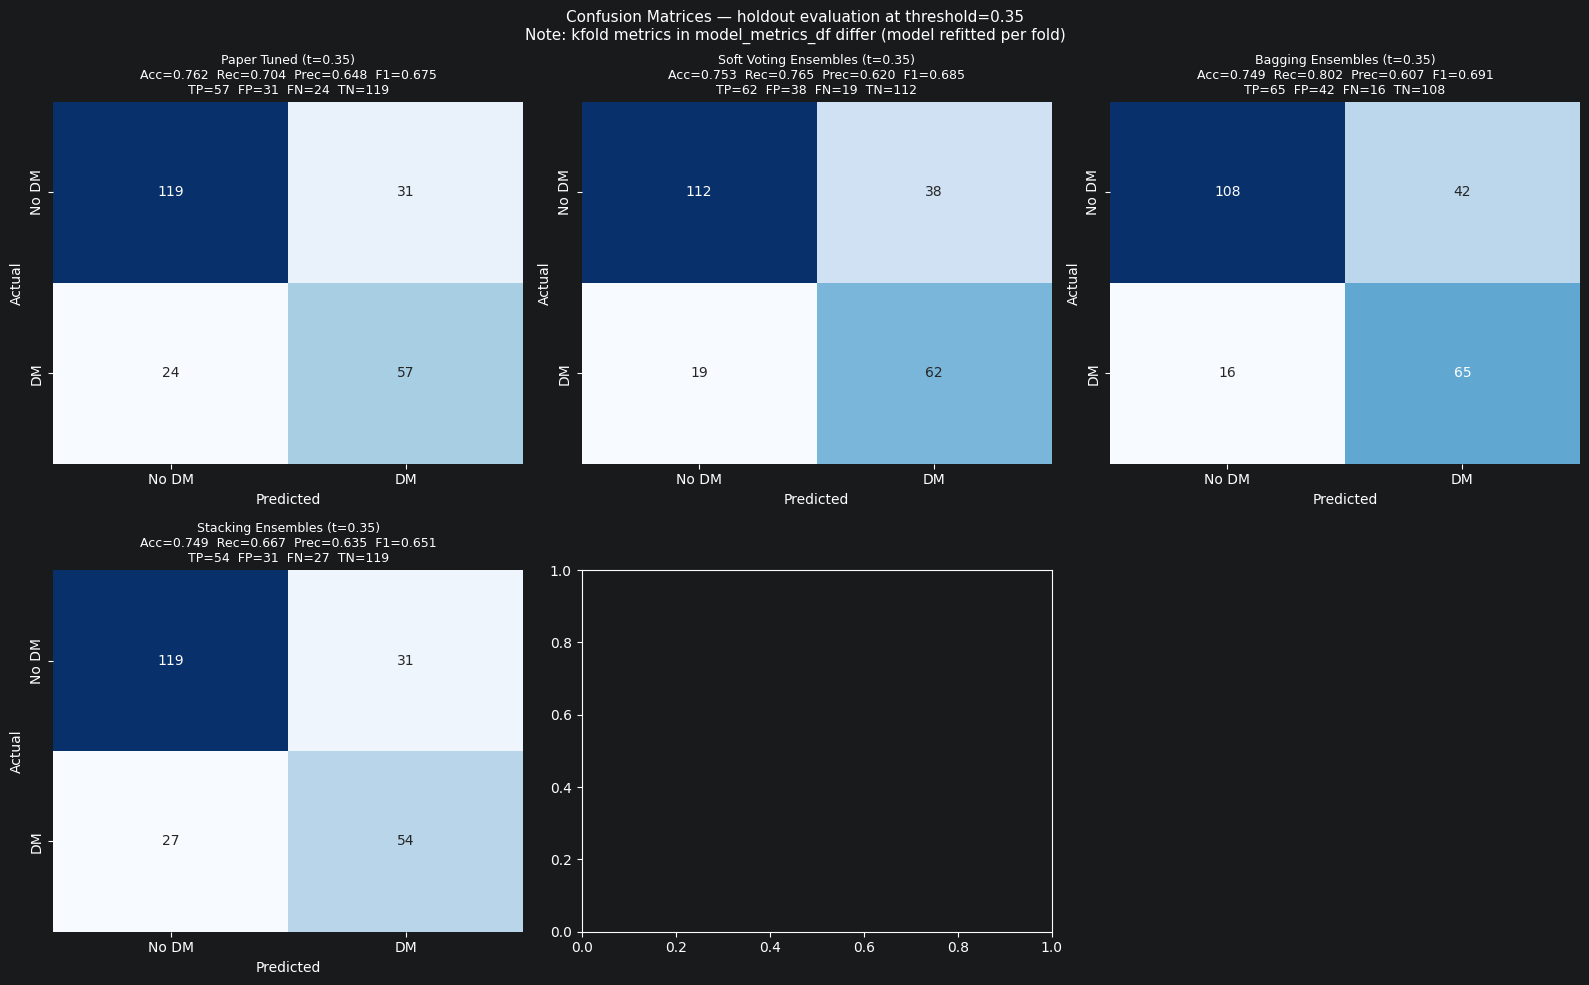

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

# ============================================================
# Confusion Matrices — all models at threshold=0.35
# Single holdout, consistent with model training
#
# Each model uses its own correct test set:
#   LR        → X_test_paper_scaled  (6 features, RobustScaled)
#   DT        → X_tree_test          (5 features, unscaled, original indices)
#   Ensembles → X_test               (6 features, unscaled — internal Pipelines scale)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

models_to_plot = [
    (model_registry[model_names['paper-lr']],        model_data_map[model_names['paper-lr']][0], model_data_map[model_names['paper-lr']][1], model_names['paper-lr']),
    (model_registry[model_names['ensemble-1']],        model_data_map[model_names['ensemble-1']][0], model_data_map[model_names['ensemble-1']][1], model_names['ensemble-1']),
    (model_registry[model_names['ensemble-2']],        model_data_map[model_names['ensemble-2']][0], model_data_map[model_names['ensemble-2']][1], model_names['ensemble-2']),
    (model_registry[model_names['ensemble-3']],        model_data_map[model_names['ensemble-3']][0], model_data_map[model_names['ensemble-3']][1], model_names['ensemble-3']),

]

for i, (model, X, y_true, title) in enumerate(models_to_plot):
    # Always use predict_proba + manual threshold for consistency
    # All models in this notebook have predict_proba
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= prob_threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        cbar=False,
        xticklabels=['No DM', 'DM'],
        yticklabels=['No DM', 'DM']
    )

    acc  = accuracy_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    axes[i].set_title(
        f"{title} (t={prob_threshold})\n"
        f"Acc={acc:.3f}  Rec={rec:.3f}  Prec={prec:.3f}  F1={f1:.3f}\n"
        f"TP={tp}  FP={fp}  FN={fn}  TN={tn}",
        fontsize=9
    )
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

fig.delaxes(axes[5])
plt.suptitle(
    f'Confusion Matrices — holdout evaluation at threshold={prob_threshold}\n'
    f'Note: kfold metrics in model_metrics_df differ (model refitted per fold)',
    fontsize=11
)
plt.tight_layout()
plt.show()

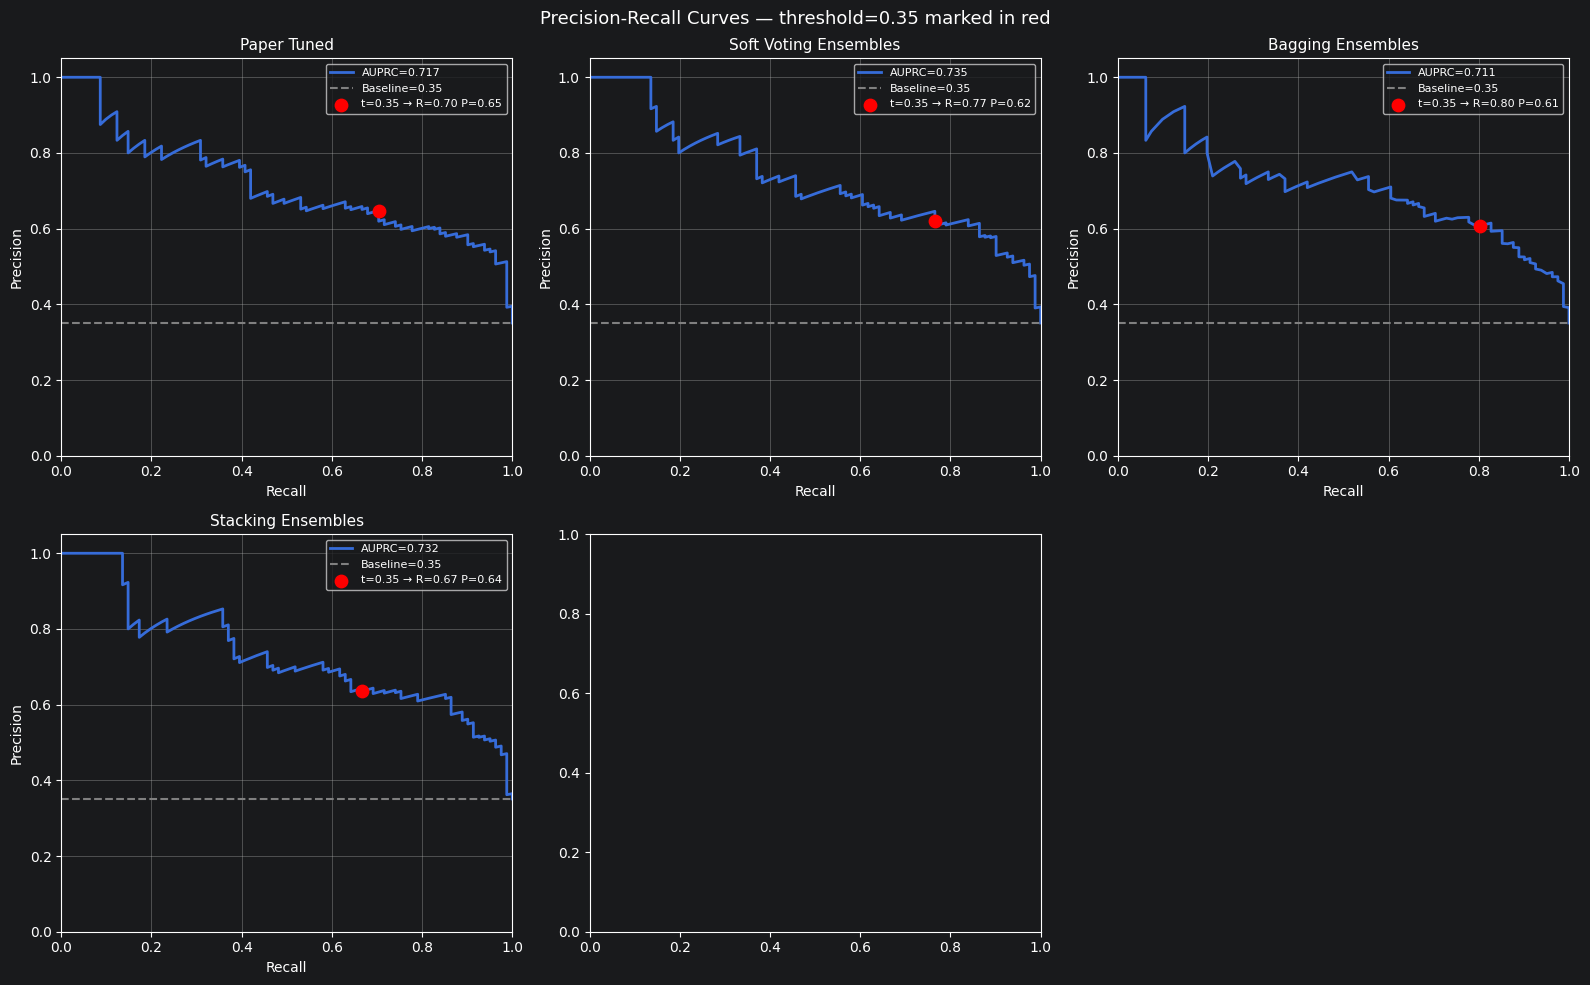

In [59]:
# ============================================================
# PR Curves — LR baseline + all ensembles
# All use predict_proba directly; no stale y_prob_paper variable
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

models_pr = [
    (model_registry[model_names['paper-lr']],        model_data_map[model_names['paper-lr']][0], model_data_map[model_names['paper-lr']][1], model_names['paper-lr']),
    (model_registry[model_names['ensemble-1']],        model_data_map[model_names['ensemble-1']][0], model_data_map[model_names['ensemble-1']][1], model_names['ensemble-1']),
    (model_registry[model_names['ensemble-2']],        model_data_map[model_names['ensemble-2']][0], model_data_map[model_names['ensemble-2']][1], model_names['ensemble-2']),
    (model_registry[model_names['ensemble-3']],        model_data_map[model_names['ensemble-3']][0], model_data_map[model_names['ensemble-3']][1], model_names['ensemble-3']),


]

for i, (model, X, y_true, name) in enumerate(models_pr):
    y_prob = model.predict_proba(X)[:, 1]

    prec_vals, rec_vals, thresholds = precision_recall_curve(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()

    axes[i].plot(rec_vals, prec_vals, linewidth=2, label=f"AUPRC={auprc:.3f}")
    axes[i].axhline(baseline, linestyle='--', color='gray',
                    label=f"Baseline={baseline:.2f}")

    # Mark the operating point at prob_threshold=0.35
    # Find the threshold index closest to 0.35
    idx = np.argmin(np.abs(thresholds - prob_threshold))
    axes[i].scatter(rec_vals[idx], prec_vals[idx],
                    color='red', zorder=5, s=80,
                    label=f"t={prob_threshold} → R={rec_vals[idx]:.2f} P={prec_vals[idx]:.2f}")

    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel("Recall")
    axes[i].set_ylabel("Precision")
    axes[i].legend(fontsize=8)
    axes[i].grid(True)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.05])

axes[5].set_visible(False)

plt.suptitle(f"Precision-Recall Curves — threshold={prob_threshold} marked in red",
             fontsize=13)
plt.tight_layout()
plt.show()

## Overall comparison of ensembles, paper logistic regression





In [60]:
def find_best_clinical_model(df):
    # Normalize key metrics
    df_score = df.copy()

    # Fill NaNs to avoid issues
    df_score['AUPRC'] = df_score['AUPRC'].fillna(0)

    # Weighted score (adjust weights if needed)
    df_score['score'] = (
            0.5 * df_score['AUPRC'] +
            0.3 * df_score['Recall'] +
            0.2 * df_score['Precision']
    )
    print(df_score[['Model', 'score']].sort_values('score',ascending=False).to_string(index=False))
    winner = df_score.loc[df_score['score'].idxmax()]

    print("\n🏆 BEST CLINICAL MODEL")
    print(f"Model : {winner['Model']}")
    print(f"Score : {winner['score']:.3f}")

    return winner

## Justification:

1. AUPRC (Area Under Precision-Recall Curve) – Weight: 50%
Why It’s the Primary Metric (50% Weight)

Designed for imbalanced data: Unlike ROC-AUC, AUPRC focuses on the positive (minority) class (diabetic patients in this case).
Directly measures clinical utility:

High AUPRC = The model is good at ranking high-risk patients at the top of its predictions.
In screening, you want to prioritize patients for limited resources (e.g., doctor follow-ups). AUPRC tells you how well the model does this.

Robust to class imbalance: ROC-AUC can be misleading when classes are imbalanced (e.g., 65% non-diabetic vs. 35% diabetic). AUPRC is not fooled by imbalance.
Clinical Justification

A model with AUPRC = 0.7 means it’s 70% better than random at identifying diabetic patients among those it flags as high-risk.
Example: If a clinic can only follow up with 20% of patients, a high AUPRC ensures the 20% most at-risk patients are selected.

2. Recall (Sensitivity) – Weight: 30%
Why It’s Critical (30% Weight)

Recall = True Positives / (True Positives + False Negatives)
Measures the model’s ability to catch diabetic patients.
Missed diabetes cases (false negatives) are catastrophic in healthcare.
Clinical Justification

A recall of 90% means the model misses only 10% of diabetic patients.
In a population of 1000 patients with 35% diabetes prevalence (~350 diabetic patients):

Recall = 90% → 35 missed cases (10% of 350).
Recall = 70% → 105 missed cases (30% of 350).

35 vs. 105 missed diagnoses is the difference between acceptable and unacceptable for a screening tool.
Trade-off with Precision

Increasing recall always decreases precision (more false positives).
But in screening, false positives are tolerable if they reduce false negatives.

3. Precision – Weight: 20%
Why It’s Secondary (20% Weight)

Precision = True Positives / (True Positives + False Positives)
Measures the proportion of predicted diabetic patients who are actually diabetic.
Lower weight because false positives are less harmful than false negatives in screening.
Clinical Justification

A precision of 60% means 40% of flagged patients are not diabetic.
While this increases follow-up costs, it’s preferable to missing 30% of diabetic patients (as in the original LR model).
False positives can be filtered out with confirmatory tests (e.g., HbA1c).



In [61]:
winning_model = find_best_clinical_model(model_metrics_df)

                Model  score
    Bagging Ensembles 0.7010
Soft Voting Ensembles 0.6985
          Paper Tuned 0.6902
   Stacking Ensembles 0.6835
         DT Validator 0.6327

🏆 BEST CLINICAL MODEL
Model : Bagging Ensembles
Score : 0.701


## Justification:

AUPRC (Area under PR Curve ) - 50%
this is a primary metric designed for imbalanceed data- unlike ROC-AUC, AUPRC focuses on the positive (minority class)
Directly measures clinical utility
High AUPRC means good at ranking high-risk patients at the top of its predictions

Clinical Justification

A model with AUPRC = 0.7 means it’s 70% better than random at identifying diabetic patients among those it flags as high-risk.
Example: If a clinic can only follow up with 20% of patients, a high AUPRC ensures the 20% most at-risk patients are selected.


Recall - 30%
Clinical Justification

A recall of 90% means the model misses only 10% of diabetic patients.
In a population of 1000 patients with 35% diabetes prevalence (~350 diabetic patients):

Recall = 90% → 35 missed cases (10% of 350).
Recall = 70% → 105 missed cases (30% of 350).

35 vs. 105 missed diagnoses is the difference between acceptable and unacceptable for a screening tool.

Remaining is Precision at 20% which is a secondary metric




In [62]:
# Final thoughts:
# - The tuned ensembl

In [63]:
import pickle
import os

os.makedirs('models', exist_ok=True)


# ✅ Get winning model name
best_model_name_clean = winning_model['Model']
best_model_obj = model_registry.get(best_model_name_clean)

if best_model_obj is None:
    raise ValueError(f"Model '{best_model_name_clean}' not found in registry")

# ✅ Create safe filename
filename = best_model_name_clean.replace(" ", "_").lower()

# ✅ Save model
with open(f"models/{filename}.pkl", "wb") as f:
    pickle.dump(best_model_obj, f)

print(f"\n✅ Best model '{best_model_name_clean}' saved to 'models/{filename}.pkl'")


✅ Best model 'Bagging Ensembles' saved to 'models/bagging_ensembles.pkl'


## Model Serving

call the diabetic_serving.py script using below command. (remember to run from same location as file)

python -m streamlit run .\diabetic_serving.py
